In [1]:
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 
import pandas as pd
import matplotlib.pyplot as plt
from ..data.sentiment import return_sentiment_chunk_data

In [55]:
desired_order = [
    'MONETARY_POLICY_AND_INFLATION', 
    'FISCAL_AND_STRUCTURAL', 
    'OTHER_IRRELEVANT', 
    'ECONOMIC_PERFORMANCE'
]

def get_topic_percentages(chunk_size):
    # Predpokladám, že return_sentiment_chunk_data máš definovanú v prostredí
    df = return_sentiment_chunk_data(chunk_size)
    df["year"] = df["date"].dt.year
    
    results = {}
    for part in ["IS", "QA"]:
        # Spočítame výskyty
        counts = df.query(f"part == '{part}'").groupby(["year", "topic"]).size().unstack(fill_value=0)
        # Normalizujeme na percentá
        pct = counts.div(counts.sum(axis=1), axis=0) * 100
        # Zoradíme stĺpce podľa desired_order (ak téma chýba, reindex ju ošetrí)
        results[part] = pct.reindex(columns=desired_order)
        
    return results

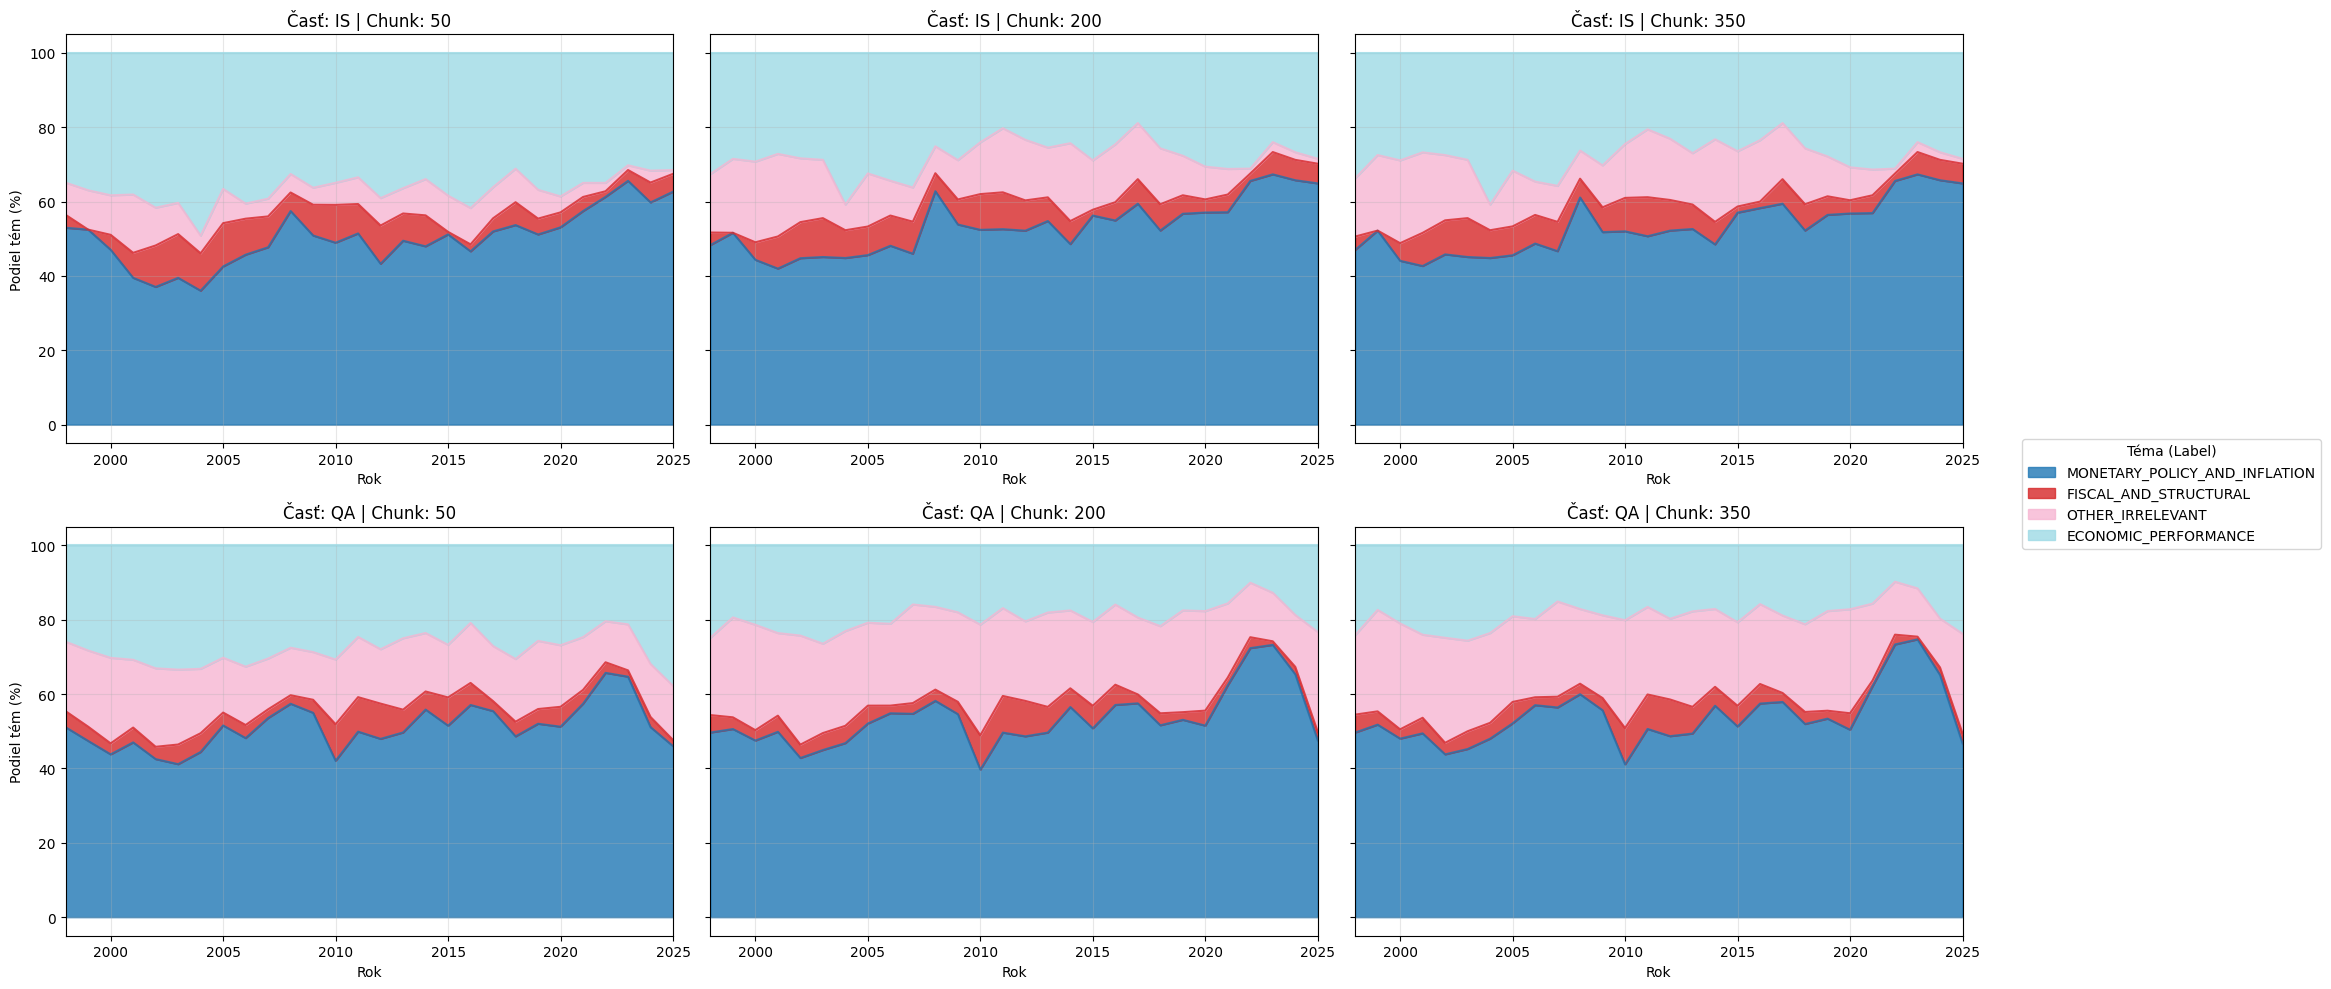

In [57]:
#3. Získanie dát pre všetky tri veľkosti
data_50 = get_topic_percentages(50)
data_200 = get_topic_percentages(200)
data_350 = get_topic_percentages(350)

# 4. Vykreslenie grafu (teraz mriežka 2 riadky x 3 stĺpce)
fig, ax = plt.subplots(2, 3, figsize=(20, 10), sharey=True)

# Pomocný zoznam pre iteráciu pri kreslení
all_data = [data_50, data_200, data_350]
chunk_sizes = [50, 200, 350]

for col_idx, size in enumerate(chunk_sizes):
    current_chunk_data = all_data[col_idx]
    
    # IS časť (horný riadok)
    current_chunk_data["IS"].plot(
        kind="area", stacked=True, alpha=0.8, colormap="tab20", ax=ax[0][col_idx], legend=False
    )
    ax[0][col_idx].set_title(f"Časť: IS | Chunk: {size}")
    
    # QA časť (dolný riadok)
    current_chunk_data["QA"].plot(
        kind="area", stacked=True, alpha=0.8, colormap="tab20", ax=ax[1][col_idx], legend=False
    )
    ax[1][col_idx].set_title(f"Časť: QA | Chunk: {size}")

# Formátovanie všetkých podgrafov
for row in ax:
    for axy in row:
        axy.set_xlabel("Rok")
        axy.set_ylabel("Podiel tém (%)")
        axy.margins(x=0)
        axy.grid(True, alpha=0.3)

# Pridanie jednej spoločnej legendy napravo
handles, labels = ax[0][0].get_legend_handles_labels()
fig.legend(handles, labels, title="Téma (Label)", bbox_to_anchor=(1.01, 0.5), loc="center left")

fig.tight_layout()
plt.show()